# S5_LOC_catboost_hpo_random_search.ipynb
## Hyperparameter Optimizing and CatBoost model training

Conda Env: scikit-learn
last edit: 13.09.2026

Copyright (c) 2026 Andreas Mätzler

All rights reserved.

You may not use, copy, modify, distribute, or reproduce this code for any purpose without explicit written permission from the author.

In [ ]:
# Core imports
import time
import datetime
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import numpy as np
import pandas as pd
import catboost as cb
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, explained_variance_score
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json, time, random
from pathlib import Path
import shap
import matplotlib.pyplot as plt

# load feature sets from common module (unchanged path/import)
sys.path.insert(0, os.path.abspath('./common'))
from feature_sets import FEATURE_SETS, SENSOR

def get_feature_cols(fs_conf):
    # Handles both list-based and dict-based FEATURE_SETS definitions
    return fs_conf["features"] if isinstance(fs_conf, dict) else fs_conf


set settings

In [2]:
RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TARGET = "SPECIFIC_YIELD"
TIMESTAMP_COL = "TIMESTAMP"

result_path = r'.\results' # path for result diagrams/CSVs
models_path = r'.\models' # path for CatBoost models

# dataset selection, smaller datasets for testing
csv_dataset = "alle_151_Netzeinspeiser"
#csv_dataset = "Radius_5000m"
#csv_dataset = "Radius_200m"

dataframe_path = '../../Daten/Solar_Load_Profile/2018_Features_Solar_Load_Profile_' + csv_dataset + '.csv'


load preprocessed data from csv, calculate TIME features and create temporal split

In [ ]:
# Load preprocessed dataset (output of S4 preprocessing stage)
df = pd.read_csv(dataframe_path, parse_dates=["TIMESTAMP"])
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)

# Time-based cyclic features
df["HOUR_DEZ"] = df["TIMESTAMP"].dt.hour + df["TIMESTAMP"].dt.minute / 60
df["DAY_YEAR"] = df["TIMESTAMP"].dt.dayofyear

# Cyclic encoding improves model learning of seasonality
df["SIN_HOUR"] = np.sin(2 * np.pi * df["HOUR_DEZ"] / 24)
df["COS_HOUR"] = np.cos(2 * np.pi * df["HOUR_DEZ"] / 24)
# df["SIN_DAY"] = np.sin(2 * np.pi * df["DAY_YEAR"] / 365)
df["COS_DAY"] = np.cos(2 * np.pi * df["DAY_YEAR"] / 365)

# Holdout: last 5 days of every month in 2018 -> temporal test set, no leakage
df["day_of_month"] = df[TIMESTAMP_COL].dt.day
df["days_in_month"] = df[TIMESTAMP_COL].dt.days_in_month
holdout_mask = df["day_of_month"] > (df["days_in_month"] - 5)

testdf = df.loc[holdout_mask].copy()
traindf = df.loc[~holdout_mask].copy()

print(f"Train: {traindf.shape[0]} rows | Holdout test: {testdf.shape[0]} rows")


Train: 1891802 rows | Holdout test: 378137 rows


define metrics

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def maape(y_true, y_pred, eps=1e-10):
    # Bounded alternative to MAPE, robust for near-zero night values
    errors = np.asarray(y_true) - np.asarray(y_pred)
    return np.mean(np.arctan(np.abs(errors / (np.asarray(y_true) + eps))))

def skill_score(rmse_model, rmse_persistence):
    return 1 - (rmse_model / rmse_persistence)

def regression_results_core(y_true, y_pred, rmse_persistence=None):
    # Focused metric set: RMSE, R2, MAAPE, SkillScore
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    results = {}
    n = len(y_true)
    results["N Samples"] = n
    results["RMSE"] = rmse(y_true, y_pred)
    results["R2"] = np.nan if n < 2 else r2_score(y_true, y_pred)
    results["MAAPE"] = maape(y_true, y_pred)
# Secondary metrics
    if rmse_persistence is not None:
        results["SkillScore"] = skill_score(results["RMSE"], rmse_persistence)   
    results["MAE"] = mean_absolute_error(y_true, y_pred)
    results["median AE"] = median_absolute_error(y_true, y_pred)
    results["explained Variance"] = explained_variance_score(y_true, y_pred)
    results["Bias"] = (y_true - y_pred).mean()
    return results


create persistance data for skillscore

In [ ]:
LEAD_STEPS = 1 
testdf = testdf.sort_values(TIMESTAMP_COL)
testdf["y_persistence"] = testdf.groupby(testdf[TIMESTAMP_COL].dt.date)[TARGET].shift(LEAD_STEPS)
persist_eval = testdf.dropna(subset=["y_persistence"])
rmse_persistence = rmse(persist_eval[TARGET], persist_eval["y_persistence"])
print(f"Persistence RMSE (holdout): {rmse_persistence:.4f}")


Persistence RMSE (holdout): 0.1281


do hyperparameter optimizing (HPO)

In [ ]:
PARAM_SPACE = {
    "depth": [4, 6, 8, 10],
    "learning_rate": np.linspace(0.03, 0.3, 10).tolist(),
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "bagging_temperature": np.linspace(0, 1, 6).tolist(),
    "border_count": [64, 128, 254],
}
N_ITER_HPO = 200  # 200 as default
N_SPLITS_CV = 6

# Internal validation split, strictly before holdout in time -> avoids leakage
train_sorted = traindf.sort_values(TIMESTAMP_COL)
val_cutoff = train_sorted[TIMESTAMP_COL].quantile(0.85)
fit_mask = train_sorted[TIMESTAMP_COL] <= val_cutoff
val_mask = ~fit_mask

def sample_params(space, rng):
    return {k: rng.choice(v) for k, v in space.items()}

def run_hpo_for_feature_set(fs_name, feature_cols, rng):
    X_fit = train_sorted.loc[fit_mask, feature_cols].astype(np.float32)
    y_fit = train_sorted.loc[fit_mask, TARGET]
    X_val = train_sorted.loc[val_mask, feature_cols].astype(np.float32)
    y_val = train_sorted.loc[val_mask, TARGET]

    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
    best_score, best_params = np.inf, None

    for i in range(N_ITER_HPO):
        params = sample_params(PARAM_SPACE, rng)
        cv_scores = []
        for train_idx, cv_val_idx in tscv.split(X_fit):
            model = CatBoostRegressor(
                loss_function="RMSE", eval_metric="RMSE",
                od_type="Iter", od_wait=50, iterations=2000,
                random_seed=RANDOM_SEED, task_type="GPU",
                has_time=True, allow_writing_files=False, verbose=False,
                **params,
            )
            model.fit(
                X_fit.iloc[train_idx], y_fit.iloc[train_idx],
                eval_set=(X_fit.iloc[cv_val_idx], y_fit.iloc[cv_val_idx]),
                use_best_model=True, verbose=False,
            )
            preds = model.predict(X_fit.iloc[cv_val_idx])
            cv_scores.append(rmse(y_fit.iloc[cv_val_idx], preds))
        mean_cv_rmse = np.mean(cv_scores)
        if mean_cv_rmse < best_score:
            best_score, best_params = mean_cv_rmse, params

    # Final early-stopped fit on fit/val split to get best_iteration_
    final_hpo_model = CatBoostRegressor(
        loss_function="RMSE", eval_metric="RMSE",
        od_type="Iter", od_wait=50, iterations=3000,
        random_seed=RANDOM_SEED, task_type="GPU",
        has_time=True, allow_writing_files=False, verbose=False,
        **best_params,
    )
    final_hpo_model.fit(X_fit, y_fit, eval_set=(X_val, y_val), use_best_model=True, verbose=200)

    return {
        "feature_set": fs_name,
        "best_params": best_params,
        "best_iteration": final_hpo_model.get_best_iteration(),
        "cv_rmse": best_score,
    }

rng = np.random.default_rng(RANDOM_SEED)
hpo_results = {}
for fs_name, fs_conf in FEATURE_SETS.items():
    feature_cols = get_feature_cols(fs_conf)
    current_time = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{current_time}] Running HPO for {fs_name} ...")
    hpo_results[fs_name] = run_hpo_for_feature_set(fs_name, feature_cols, rng)

pd.DataFrame(hpo_results).T.to_csv(result_path + "/S5_LOC_hpo_results_per_feature_set.csv", index=False, sep=";", decimal=",", encoding="utf-8-sig")

[22:32:33] Running shortened HPO for FS1_TIME ...
0:	learn: 0.2187129	test: 0.1814930	best: 0.1814930 (0)	total: 10.1ms	remaining: 30.3s
bestTest = 0.1243278377
bestIteration = 38
Shrink model to first 39 iterations.
[23:02:10] Running shortened HPO for FS2_GIS_TIME ...
0:	learn: 0.2137578	test: 0.1749295	best: 0.1749295 (0)	total: 13.7ms	remaining: 41.1s
bestTest = 0.1245992673
bestIteration = 26
Shrink model to first 27 iterations.
[23:35:39] Running shortened HPO for FS3_GIS_SENSOR_TIME ...
0:	learn: 0.2018766	test: 0.1670878	best: 0.1670878 (0)	total: 17.5ms	remaining: 52.4s
200:	learn: 0.0678097	test: 0.0694380	best: 0.0692215 (181)	total: 3.55s	remaining: 49.5s
bestTest = 0.06922147127
bestIteration = 181
Shrink model to first 182 iterations.
[00:49:27] Running shortened HPO for FS4_SEV4_TIME ...
0:	learn: 0.2173613	test: 0.1813779	best: 0.1813779 (0)	total: 13.5ms	remaining: 40.4s
bestTest = 0.1103503581
bestIteration = 31
Shrink model to first 32 iterations.
[01:22:58] Running 

final training for each feature-set without holdout-data

In [7]:
final_models = {}
for fs_name, fs_conf in FEATURE_SETS.items():
    feature_cols = get_feature_cols(fs_conf)
    res = hpo_results[fs_name]
    X_train_full = traindf[feature_cols].astype(np.float32)
    y_train_full = traindf[TARGET]

    model = CatBoostRegressor(
        loss_function="RMSE", random_seed=RANDOM_SEED, task_type="GPU",
        has_time=True, allow_writing_files=False, verbose=False,
        iterations=res["best_iteration"],
        **res["best_params"],
    )
    model.fit(X_train_full, y_train_full, verbose=100)
    model.save_model(f"{models_path}/model_{fs_name}.cbm")
    final_models[fs_name] = model
    current_time = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{current_time}] {fs_name}: trained with {res['best_iteration']} iterations")


NameError: name 'hpo_results' is not defined

create metric results

In [8]:
metrics_all = {}
for fs_name, fs_conf in FEATURE_SETS.items():
    feature_cols = get_feature_cols(fs_conf)
    X_test = testdf[feature_cols].astype(np.float32)
    y_test = testdf[TARGET]
    preds = final_models[fs_name].predict(X_test)
    metrics_all[fs_name] = regression_results_core(y_test, preds, rmse_persistence=rmse_persistence)

metrics_df = pd.DataFrame(metrics_all).T
metrics_df.to_csv(result_path + "/S5_LOC_metrics_summary.csv", index=True, sep=";", decimal=",", encoding="utf-8-sig")
metrics_df[["RMSE", "R2", "MAAPE", "MAE", "SkillScore"]]


,RMSE,R2,MAAPE,MAE,SkillScore
FS1_TIME,0.154806,0.551631,0.593463,0.114453,-0.208840
FS2_GIS_TIME,0.150800,0.574538,0.579189,0.111245,-0.177554
FS3_GIS_SENSOR_TIME,0.070171,0.907876,0.284265,0.040773,0.452056
FS4_SEV4_TIME,0.112375,0.763736,0.523577,0.079102,0.122495
FS5_SEV4_GIS_TIME,0.086803,0.859029,0.409196,0.058251,0.322178
FS6_SEV4_GIS_SENSOR_TIME,0.061873,0.928375,0.261555,0.035411,0.516850
FS7_SEV12_TIME,0.104094,0.797272,0.449402,0.070173,0.187155
FS8_SEV12_GIS_TIME,0.079349,0.882201,0.387769,0.052395,0.380386
FS9_SEV12_GIS_SENSOR_TIME,0.061770,0.928614,0.264066,0.035565,0.517656


create comparison chart:  R2, RMSE and MAAPE across feature sets

In [ ]:
# for testing without rerunning HPO
# metrics_df = pd.read_csv(result_path + "/S5_LOC_metrics_summary.csv", sep=";", decimal=",", encoding="utf-8-sig", index_col=0)

metrics_long = metrics_df.reset_index().rename(columns={"index": "Feature Set"})
metric_names = ["R2","RMSE","MAAPE"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]  # blue / green / orange, one color per metric

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f"{m} (niedriger ist besser)" if m != "R2" else f"{m} (höher ist besser)" for m in metric_names],
    horizontal_spacing=0.12,
)

for i, metric in enumerate(metric_names, start=1):
    max_val = metrics_long[metric].max()
    fig.add_trace(
        go.Bar(
            x=metrics_long[metric],
            y=metrics_long["Feature Set"],
            orientation="h",
            marker_color=colors[i - 1],
            text=metrics_long[metric].round(3),
            textposition="outside",
            cliponaxis=False,  # keep value labels visible outside bar, not clipped
            name=metric,
            showlegend=False,
        ),
        row=1, col=i,
    )
    fig.update_xaxes(
        title_text=metric, showgrid=True, gridcolor="rgba(0,0,0,0.1)",
        range=[0, max_val * 1.25],  # extra headroom for outside labels
        row=1, col=i,
    )
    fig.update_yaxes(autorange="reversed", row=1, col=i)  # best feature set on top, consistent order

fig.update_layout(
    template="plotly_white",  # built-in default template, renders outside Perplexity too
    title_text="Metriken aus Modelltraining: RMSE, r² und MAAPE je Featureset (Holdout-Test)",
    height=500,
    width=1600,
    margin=dict(t=100, r=40, l=60),
)

fig.write_image(result_path + "/S5_LOC_r2_rmse_maape_comparison.png", scale=3)
fig.show()
fig.write_html(result_path + "/S5_LOC_r2_rmse_maape_comparison.html")  # keep interactive version as result

start SHAP-analysis for each feature set for diagrams

In [ ]:
# Load final models from disk for later use
final_models = {}
for fs_name in FEATURE_SETS.keys():
    model = CatBoostRegressor()
    model.load_model(f"{models_path}/model_{fs_name}.cbm")
    final_models[fs_name] = model

print(f"{len(final_models)} Modelle erfolgreich aus {models_path} geladen.")

9 Modelle erfolgreich aus .\models geladen.


create top 15 featuer diagrams and export results to csv

In [ ]:
shap_summary = {}
shap_rows = []  # Collect rows for combined CSV export

for fs_name, fs_conf in FEATURE_SETS.items():
    feature_cols = get_feature_cols(fs_conf)
    explainer = shap.TreeExplainer(final_models[fs_name])

    X_sample = testdf[feature_cols].astype(np.float32).sample(
        n=min(5000, len(testdf)),
        random_state=RANDOM_SEED
    )

    shap_values = explainer.shap_values(X_sample)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # Sort descending: highest global importance first
    shap_summary[fs_name] = pd.Series(
        mean_abs_shap, index=feature_cols
    ).sort_values(ascending=False)

    # Store rank per feature for cross-feature-set comparison
    ranked = shap_summary[fs_name].rank(ascending=False, method="first").astype(int)
    for feature_name, shap_val in shap_summary[fs_name].items():
        shap_rows.append({
            "FEATURE_SET": fs_name,
            "FEATURE_NAME": feature_name,
            "MEAN_ABS_SHAP": shap_val,
            "RANK": int(ranked[feature_name]),
            "N_SAMPLES": len(X_sample),
        })

    top_features = shap_summary[fs_name].head(15)

    fig = px.bar(
        x=top_features.values,
        y=top_features.index,
        orientation="h",
        title=f"Top 15 SHAP features: {fs_name}"
    )

    # Display the most important feature at the top
    fig.update_yaxes(
        title_text="Feature Name",
        title_font=dict(size=14),
        categoryorder="array",
        categoryarray=top_features.index[::-1]
    )
    fig.update_xaxes(
        title_text="Mean absolute SHAP value",
        title_font=dict(size=14)
    )

    fig.write_image(result_path + f"/S5_LOC_shap_{fs_name}.png", scale=2)
    fig.show()

# Combine all feature sets into one long-format dataframe
df_shap_all = pd.DataFrame(shap_rows).sort_values(["FEATURE_SET", "RANK"]).reset_index(drop=True)

output_file = result_path + "/S5_LOC_shap_all_featuresets.csv"
df_shap_all.to_csv(output_file, index=False, sep=";", decimal=",", encoding="utf-8-sig")
print(f"Export: {output_file} ({len(df_shap_all)} Zeilen, {df_shap_all['FEATURE_SET'].nunique()} Feature-Sets)")

# Pivot view: feature x feature-set, for quick Excel comparison
df_shap_pivot = df_shap_all.pivot(index="FEATURE_NAME", columns="FEATURE_SET", values="MEAN_ABS_SHAP")
pivot_file = result_path + "/S5_LOC_shap_all_featuresets_pivot.csv"
df_shap_pivot.to_csv(pivot_file,sep=";", decimal=",", encoding="utf-8-sig")
print(f"Export: {pivot_file}")

Exportiert: .\results/S5_LOC_shap_all_featuresets.csv (114 Zeilen, 9 Feature-Sets)
Exportiert: .\results/S5_LOC_shap_all_featuresets_pivot.csv


create SHAP bee-swarm diagrams for several feature-sets

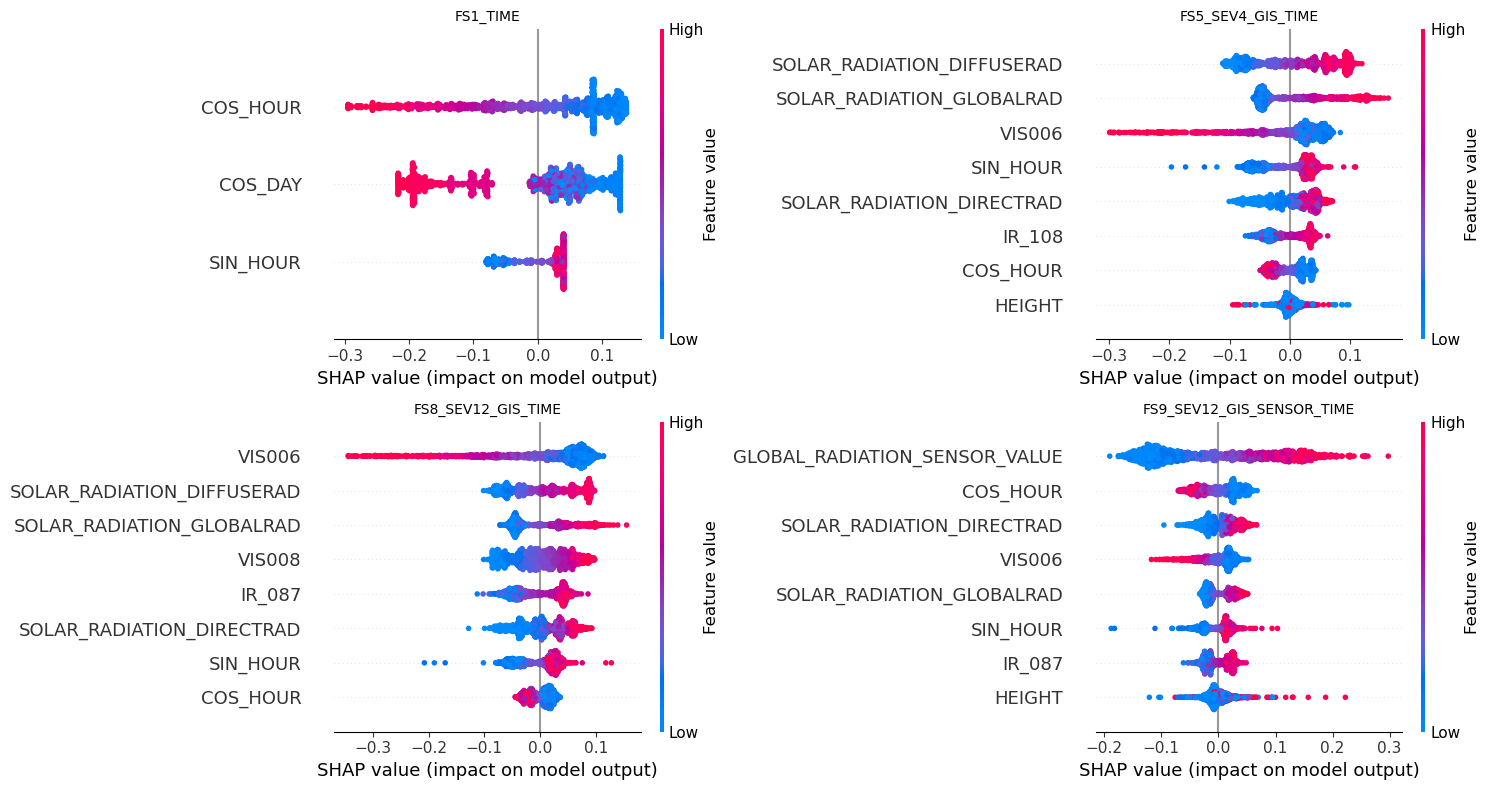

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()

selected_sets = ["FS1_TIME", "FS5_SEV4_GIS_TIME", "FS8_SEV12_GIS_TIME", "FS9_SEV12_GIS_SENSOR_TIME"]

# loop through selected feature sets
for i, fs_name in enumerate(selected_sets):
    plt.sca(axes[i])
    feature_cols = get_feature_cols(FEATURE_SETS[fs_name])
    explainer = shap.TreeExplainer(final_models[fs_name])
    X_sample = testdf[feature_cols].astype(np.float32).sample(n=1500, random_state=55)
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, show=False, max_display=8, plot_size=None)
    axes[i].set_title(fs_name, fontsize=10)

plt.tight_layout()
plt.savefig(result_path + "/S5_LOC_shap_summary_grid.png", dpi=300, bbox_inches="tight")

structured result analysis for each research question

In [ ]:
# TF1: Effect of topography and potential radiation features
tf1_pairs = [("FS1_TIME", "FS2_GIS_TIME")]  # adjust names to actual FS keys

def compare_feature_sets(df_metrics, pairs, label):
    rows = []
    for fs_a, fs_b in pairs:
        row = {
            "comparison": f"{fs_a} vs {fs_b}",
            "RMSE_A": df_metrics.loc[fs_a, "RMSE"], "RMSE_B": df_metrics.loc[fs_b, "RMSE"],
            "delta_RMSE": df_metrics.loc[fs_a, "RMSE"] - df_metrics.loc[fs_b, "RMSE"],
            "R2_A": df_metrics.loc[fs_a, "R2"], "R2_B": df_metrics.loc[fs_b, "R2"],
            "MAAPE_A": df_metrics.loc[fs_a, "MAAPE"], "MAAPE_B": df_metrics.loc[fs_b, "MAAPE"],
        }
        rows.append(row)
    result = pd.DataFrame(rows)
    result.to_csv(result_path + f"/S5_LOC_{label}_comparison.csv", index=False, sep=";", decimal=",", encoding="utf-8-sig")
    return result

tf1_result = compare_feature_sets(metrics_df, tf1_pairs, "TF1")
tf1_result


,comparison,RMSE_A,RMSE_B,delta_RMSE,R2_A,R2_B,MAAPE_A,MAAPE_B
0,FS1_TIME vs FS2_GIS_TIME,0.154806,0.1508,0.004006,0.551631,0.574538,0.593463,0.579189


In [ ]:
# TF2: Error structure by time of day
testdf["hour"] = testdf[TIMESTAMP_COL].dt.hour
tf2_rows = []
for fs_name, fs_conf in FEATURE_SETS.items():
    feature_cols = get_feature_cols(fs_conf)
    X_test = testdf[feature_cols].astype(np.float32)
    preds = final_models[fs_name].predict(X_test)
    err = np.abs(testdf[TARGET].values - preds)
    tf2_rows.append(pd.DataFrame({"feature_set": fs_name, "hour": testdf["hour"], "abs_error": err}))

tf2_df = pd.concat(tf2_rows)
tf2_hourly = tf2_df.groupby(["feature_set", "hour"])["abs_error"].mean().reset_index()
tf2_hourly.to_csv(result_path + "/S5_LOC_TF2_hourly_error.csv", index=False, sep=";", decimal=",", encoding="utf-8-sig")

fig = px.line(tf2_hourly, x="hour", y="abs_error", color="feature_set",
              title="Mean absolute error by hour of day")
fig.write_image(result_path + "/S5_LOC_TF2_hourly_error.png", scale=2)
fig.show()


In [ ]:
# TF3: Added value of ground sensor data
tf3_pairs = [
    ("FS2_GIS_TIME", "FS3_GIS_SENSOR_TIME"),
    ("FS5_SEV4_GIS_TIME", "FS6_SEV4_GIS_SENSOR_TIME"),
    ("FS8_SEV12_GIS_TIME", "FS9_SEV12_GIS_SENSOR_TIME"),
]  # adjust names to actual FS keys
tf3_result = compare_feature_sets(metrics_df, tf3_pairs, "TF3")
tf3_result


NameError: name 'compare_feature_sets' is not defined

In [14]:
# TF4: 4-band vs 12-band SEVIRI comparison
tf4_pairs = [
    ("FS4_SEV4_TIME", "FS7_SEV12_TIME"),
    ("FS5_SEV4_GIS_TIME", "FS8_SEV12_GIS_TIME"),
    ("FS6_SEV4_GIS_SENSOR_TIME", "FS9_SEV12_GIS_SENSOR_TIME"),
]  # adjust names to actual FS keys
tf4_result = compare_feature_sets(metrics_df, tf4_pairs, "TF4")
tf4_result


,comparison,RMSE_A,RMSE_B,delta_RMSE,R2_A,R2_B,MAAPE_A,MAAPE_B
0,FS4_SEV4_TIME vs FS7_SEV12_TIME,0.112375,0.104094,0.008281,0.763736,0.797272,0.523577,0.449402
1,FS5_SEV4_GIS_TIME vs FS8_SEV12_GIS_TIME,0.086803,0.079349,0.007454,0.859029,0.882201,0.409196,0.387769
2,FS6_SEV4_GIS_SENSOR_TIME vs FS9_SEV12_GIS_SENS...,0.061873,0.061770,0.000103,0.928375,0.928614,0.261555,0.264066


SHAP Compare of Top 3-Feature for each feature-set


In [17]:
top_features_summary = pd.DataFrame({
    fs_name: shap_summary[fs_name].tail(3).index.tolist()[::-1]
    for fs_name in FEATURE_SETS.keys()
}).T
top_features_summary.columns = [f"Top{i+1}" for i in range(3)]
top_features_summary.to_csv(result_path + "/S5_LOC_shap_top3_per_feature_set.csv", index=True, sep=";", decimal=",", encoding="utf-8-sig")
top_features_summary

,Top1,Top2,Top3
FS1_TIME,COS_HOUR,COS_DAY,SIN_HOUR
FS2_GIS_TIME,COS_DAY,SOLAR_RADIATION_GLOBALRAD,SOLAR_RADIATION_DIFFUSERAD
FS3_GIS_SENSOR_TIME,GLOBAL_RADIATION_SENSOR_VALUE,COS_HOUR,SIN_HOUR
FS4_SEV4_TIME,COS_HOUR,COS_DAY,IR_108
FS5_SEV4_GIS_TIME,SOLAR_RADIATION_DIFFUSERAD,SOLAR_RADIATION_GLOBALRAD,VIS006
FS6_SEV4_GIS_SENSOR_TIME,GLOBAL_RADIATION_SENSOR_VALUE,COS_HOUR,VIS006
FS7_SEV12_TIME,COS_HOUR,COS_DAY,IR_087
FS8_SEV12_GIS_TIME,VIS006,SOLAR_RADIATION_DIFFUSERAD,SOLAR_RADIATION_GLOBALRAD
FS9_SEV12_GIS_SENSOR_TIME,GLOBAL_RADIATION_SENSOR_VALUE,COS_HOUR,SOLAR_RADIATION_DIRECTRAD


export metrics and SHAP values for further analysis in Excel

In [ ]:
# Full metrics export: all feature sets, all metrics, wide format
metrics_export = metrics_df.copy()
metrics_export.index.name = "feature_set"
metrics_export.to_csv(result_path + "/S5_LOC_all_metrics_export.csv", sep=";", decimal=",", encoding="utf-8-sig")
print(f"Metrics exported: {metrics_export.shape[0]} feature sets x {metrics_export.shape[1]} metrics")

# Full SHAP export: long format, all features (not just Top5), all feature sets
shap_export_rows = []
for fs_name, shap_series in shap_summary.items():
    for feature, mean_abs_shap in shap_series.items():
        shap_export_rows.append({
            "feature_set": fs_name,
            "feature": feature,
            "mean_abs_shap": mean_abs_shap,
            "rank": shap_series.rank(ascending=False)[feature],  # 1 = most important
        })

shap_export_df = pd.DataFrame(shap_export_rows).sort_values(["feature_set", "rank"])
shap_export_df.to_csv(result_path + "/S5_LOC_all_shap_values_export.csv", sep=";", decimal=",", index=False, encoding="utf-8-sig")
print(f"SHAP values exported: {shap_export_df['feature_set'].nunique()} feature sets, {len(shap_export_df)} rows total")

# Optional: pivoted wide-format SHAP table (feature_set x feature), easier for cross-set comparison
shap_wide = shap_export_df.pivot(index="feature", columns="feature_set", values="mean_abs_shap")
shap_wide.to_csv(result_path + "/S5_LOC_all_shap_values_wide.csv", sep=";", decimal=",", encoding="utf-8-sig")
print(f"SHAP wide-format table exported: {shap_wide.shape[0]} unique features x {shap_wide.shape[1]} feature sets")

Metrics exported: 9 feature sets x 9 metrics
SHAP values exported: 9 feature sets, 114 rows total
SHAP wide-format table exported: 23 unique features x 9 feature sets
